In [1]:
import numpy as np

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

import multiprocessing as mp
from tqdm import tqdm
from joblib import Parallel, delayed
import os
from scipy.spatial import ConvexHull, convex_hull_plot_2d
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from stoch_sim_model import *

plt.style.use('/Users/ObinnaUkogu/Desktop/custom.mplstyle')
%config InlineBackend.figure_format = 'retina'

In [2]:
alpha = 0.5 # antigen-cyokine weighting
psi_N_I, psi_cM_I, psi_E_I, psi_E_c = 0.5, 0.5, 0.5, 0.5 # decision to upregulate or downregulate based on stimulus

In [14]:
def agent_stoch_sim(I_0 = I_0, b_I = b_I, t1 = t1, d_IE = d_IE, T_I = T_I,
                    regulation_coeffs = [psi_N_I, psi_cM_I, psi_E_I, psi_E_c],
                    infection = "prim"):
    
    dt =  duration/steps
    
    # draw population of reponding cells for agent-based simulations
    mu_rates = np.array([g_NE_max + g_NM_max, b_E_max + g_EM_max, g_ME_max, b_c1])
    cv_rates = np.array([0.1, 0.1, 0.1, 0.5])

    div_rates = (np.random.lognormal(mean = np.log(mu_rates/np.sqrt(1 + cv_rates**2)), 
                        sigma = np.sqrt(np.log(1+ cv_rates**2)), size = (N0,4))).T
    
    # define variables for storage
    N_m = np.zeros((steps+1, N0))
    N_m[0,:] +=1

    S = np.zeros(steps+1)
    E_m = np.zeros((steps+1, N0))
    cM_m = np.zeros((steps+1, N0))
    eM_m = np.zeros((steps+1, N0))
    I = np.zeros(steps+1)

    # Run population simulation
    t = 0.0
    I[0] = I_0
    S[0] = S0
    
    for i in np.arange(1, steps + 1):
        # compute total population of cell types
        E_pop, cM_pop, eM_pop = np.sum(E_m[i-1]), np.sum(cM_m[i-1]), np.sum(eM_m[i-1])

        # run infection dynamics: replication and effector clearance
        S[i] = S[i-1] - dt*(I[i-1] >= I_0)*np.exp(-t/T_I)*I[i-1]*b_I*(S[i-1]-I[i-1])
        I[i] = I[i-1] + dt*((I[i-1] >= I_0)*np.exp(-t/T_I)*I[i-1]*b_I*(S[i-1]-I[i-1]) - d_IE*I[i-1]*E_pop - d_I*I[i-1])

        # naive cells have a timer to activation
        N_act = (np.random.exponential(1/g_N(t1,I[i-1], E_pop, Treg0, max_val = div_rates[0,:]), N0) < dt)*N_m[i-1,:]
        N_to_cM = np.random.binomial(N_act.astype(int), (1-psi_N_I)*(1-p_A(t1,I[i-1])) + psi_N_I*p_A(t1,I[i-1]), N0)

        # central memory cells divide and differentiate
        cM_div = np.random.binomial(cM_m[i-1,:].astype(int), dt*b_cM(t1,I[i-1], E_pop, Treg0, max_val = div_rates[2]), N0)
        cM_to_E = np.random.binomial(2*cM_div.astype(int), (1-psi_cM_I)*(1-p_A(t1,I[i-1])) + psi_cM_I*p_A(t1,I[i-1]), N0)

        # effector cells divide and differentiate, or die, or both
        E_div = np.random.binomial(-np.minimum(-E_m[i-1,:].astype(int),0), dt*b_E(t1,I[i-1], E_pop, Treg0, max_val = div_rates[1], b_c1_pop = np.mean(div_rates[3])), N0)
        E_to_eM = np.random.binomial(E_div.astype(int), (alpha*((1-psi_E_I)*(1-p_A(t1,I[i-1])) + psi_E_I*p_A(t1,I[i-1])) 
                                     + (1-alpha)*((1 - psi_E_c)*(1-hl_u(c1_ss(t1,I[i-1], E_pop, Treg0, np.mean(div_rates[3])), k_E)) 
                                                  + psi_E_c*hl_u(c1_ss(t1,I[i-1], E_pop, Treg0, np.mean(div_rates[3])), k_E))), N0)
        E_death = np.random.binomial(-np.minimum(-E_m[i-1,:].astype(int),0), dt*d_E(t1,I[i-1], E_pop, Treg0, b_E_pop = div_rates[2], b_c1_pop = np.mean(div_rates[3])), N0)

        E_to_M_death = np.random.binomial(E_to_eM.astype(int), alpha*((1-psi_E_I)*(1-p_A(t1,I[i-1])) + psi_E_I*p_A(t1,I[i-1])) 
                                      + (1-alpha)*((1 - psi_E_c)*hl_u(c1_ss(t1,I[i-1], E_pop, Treg0, np.mean(div_rates[3])), k_E) 
                                                   + psi_E_c*hl_u(c1_ss(t1,I[i-1], E_pop, Treg0, np.mean(div_rates[3])), k_E)), N0)


        # Update population dynamics
        N_m[i,:] = N_m[i-1,:] - N_act
        cM_m[i,:] = N_to_cM + (cM_m[i-1,:] - cM_div + 2*cM_div - cM_to_E) 
        E_m[i,:] = (N_act - N_to_cM) + cM_to_E + (E_m[i-1,:] + E_div - 2*E_to_eM) - (E_death - E_to_M_death) 
        eM_m[i,:] = eM_m[i-1,:] + (E_to_eM - E_to_M_death)

        # increment time
        t += dt
        
        # Collect population dynamics
        N, cM, E, eM = np.sum(N_m, axis = 1), np.sum(cM_m, axis = 1), np.sum(E_m, axis = 1), np.sum(eM_m, axis = 1)
        ts = np.linspace(0, duration, steps + 1)
    
    return np.array(regulation_coeffs), I, N, E, cM, eM, Treg0, ts

In [15]:
_, I, N, E, cM, eM, T, ts = agent_stoch_sim(I_0 = I_0, b_I = b_I, t1 = t1, d_IE = d_IE, T_I = T_I,
                    regulation_coeffs = [psi_N_I, psi_cM_I, psi_E_I, psi_E_c],
                    infection = "prim")

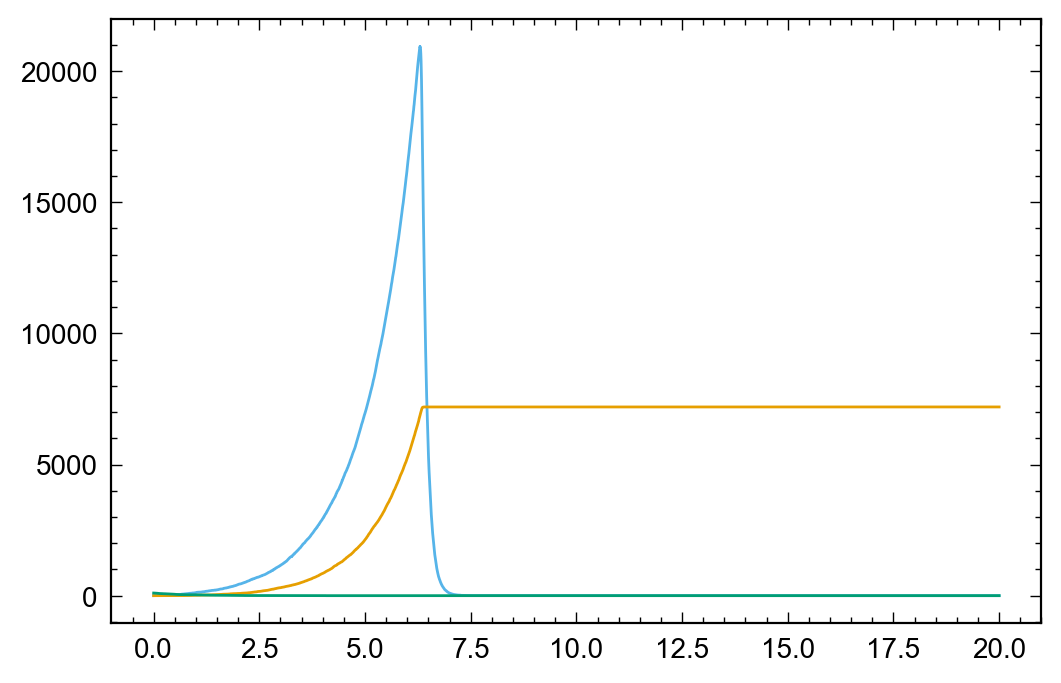

In [16]:
plt.plot(ts,E)
plt.plot(ts,eM)
plt.plot(ts,N)

1409.3791098544757

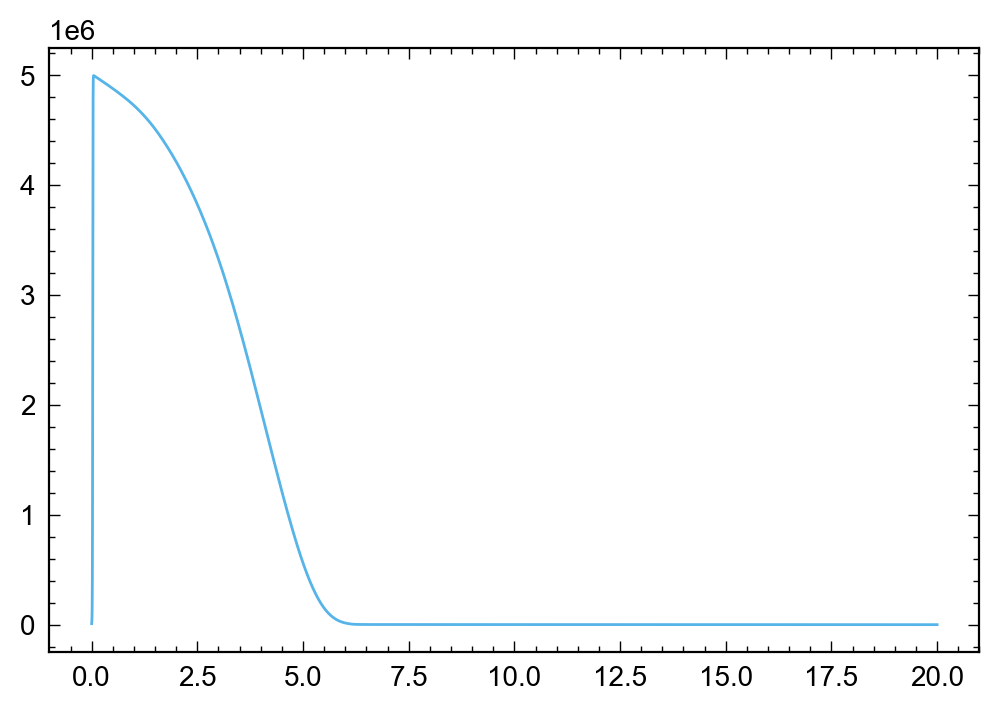

In [7]:
plt.plot(ts,I)
np.min(I[1000:4000])

In [ ]:
plt.plot(ts, alpha*((1-psi_E_I)*(1-p_A(t1,I)) + psi_E_I*p_A(t1,I)) 
                                 + (1-alpha)*((1 - psi_E_c)*hl_u(c1_ss(t1,I, E_pop, Treg0, np.mean(div_rates[3])), k_E) 
                                              + psi_E_c*hl_u(c1_ss(t1,I, E_pop, Treg0, np.mean(div_rates[3])), k_E)))

In [ ]:
plt.plot(ts,store)